<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/3B_EWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymupdf transformers torch pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 93.0 MB/s eta 0:00:00


In [ ]:
import fitz
import pandas as pd
# Quarterly Earnings Presentation
# pdf_path = "/content/earnings_presentation_q4_fy26_v1.pdf"
# Valuation Report
# pdf_path = "/content/eop_reit_valuation_report_march_2026.pdf"
# Earnigns call report for DLF
pdf_path = "/content/Q4-Transcript-18-05-24.pdf"
doc = fitz.open(pdf_path)

pages = []

for page_num in range(len(doc)):
    text = doc.load_page(page_num).get_text()
    pages.append({
        "page": page_num + 1,
        "text": text
    })

df = pd.DataFrame(pages)

print(df.head())

   page                                               text
0     1   \n \nPage 1 of 19 \n \n \n“DLF Limited \n Q4 ...
1     2   \nDLF Limited \nMay 14, 2024 \n \n \nPage 2 o...
2     3   \nDLF Limited \nMay 14, 2024 \n \n \nPage 3 o...
3     4   \nDLF Limited \nMay 14, 2024 \n \n \nPage 4 o...
4     5   \nDLF Limited \nMay 14, 2024 \n \n \nPage 5 o...


In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
        model="ProsusAI/finbert"
        )

In [ ]:
results = []

for idx, row in df.iterrows():
    text = row["text"][:512]
    try:
        sentiment = classifier(text)[0]
        results.append({
            "page": row["page"],
            "label": sentiment["label"],
            "score": sentiment["score"]
        })
    except:
        results.append({
            "page": row["page"],
            "label": "ERROR",
            "score": 0
        })

sentiment_df = pd.DataFrame(results)
sentiment_df.head()

,page,label,score
0,1,neutral,0.939993
1,2,neutral,0.862969
2,3,neutral,0.943208
3,4,neutral,0.915923
4,5,neutral,0.915567


In [ ]:
sentiment_df

,page,label,score
0,1,neutral,0.939993
1,2,neutral,0.862969
2,3,neutral,0.943208
3,4,neutral,0.915923
4,5,neutral,0.915567
5,6,neutral,0.927712
6,7,neutral,0.859596
7,8,neutral,0.727811
8,9,neutral,0.892263
9,10,neutral,0.851063


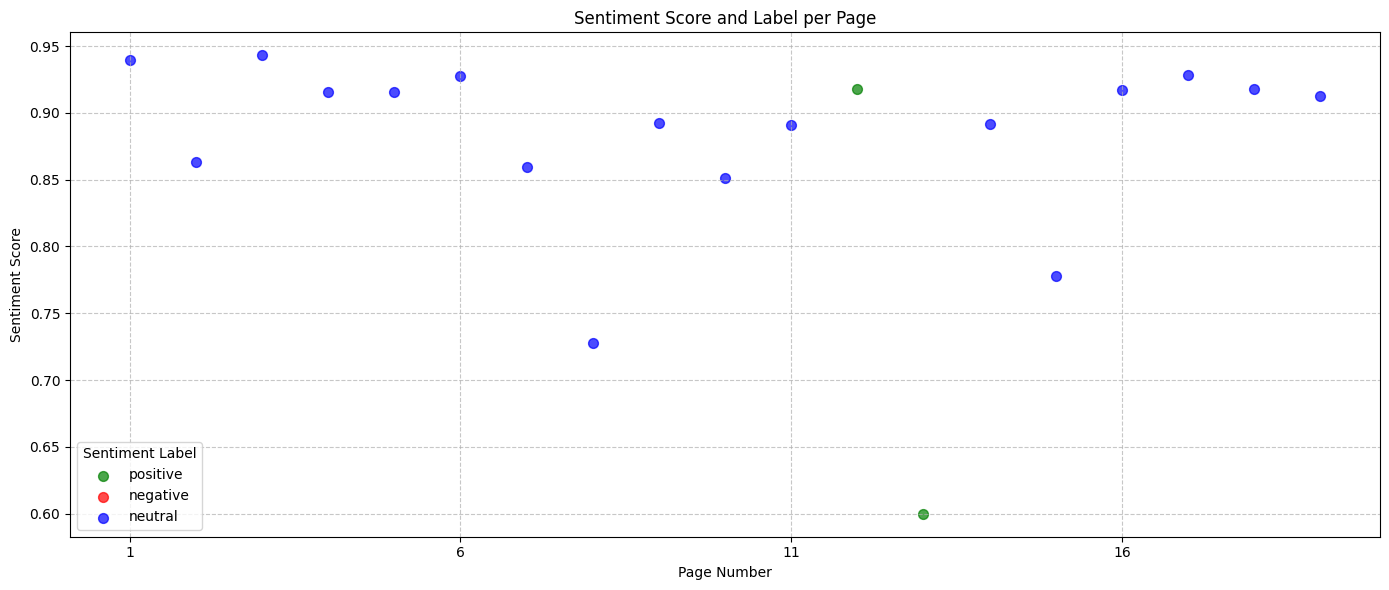

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a color map for sentiments
colors = {'positive': 'green', 'negative': 'red', 'neutral': 'blue'}

plt.figure(figsize=(14, 6))

# Plot scatter points for each sentiment label with different colors
for label, color in colors.items():
    subset = sentiment_df[sentiment_df['label'] == label]
    plt.scatter(subset['page'], subset['score'], color=color, label=label, s=50, alpha=0.7)

plt.xlabel("Page Number")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Score and Label per Page")
# Adjust x-axis ticks for better readability, showing page numbers every 5 pages
plt.xticks(np.arange(min(sentiment_df['page']), max(sentiment_df['page'])+1, 5))
plt.legend(title="Sentiment Label")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
risk_words = [
    "vacancy",
    "liquidity",
    "uncertainty",
    "risk",
    "slowdown",
    "headwinds",
    "debt",
    "macro",
    "volatility"
]

def count_risk_words(text):

    text = text.lower()

    count = 0

    found = []

    for word in risk_words:

        if word in text:
            count += 1
            found.append(word)

    return count, found

In [ ]:
risk_counts = []

for idx, row in df.iterrows():
    count, found = count_risk_words(row["text"])
    risk_counts.append({
        "page": row["page"],
        "risk_count": count,
        "keywords": found
    })

risk_df = pd.DataFrame(risk_counts)

risk_df.head()

In [ ]:
final_df = sentiment_df.merge(
    risk_df,
    on="page"
)

final_df.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    final_df["page"],
    final_df["risk_count"]
)

plt.xlabel("Page")
plt.ylabel("Governance Signal Density")
plt.title("CRE Governance Risk Signals")

plt.show()

In [ ]:
import re

valuation_keywords = [
    "valuation",
    "approach",
    "methodology",
    "discounted cash flow",
    "DCF",
    "asset-based",
    "market multiple",
    "income approach",
    "cost approach",
    "appraisal"
]

# Create a regex pattern to search for any of the keywords, case-insensitive
pattern = re.compile(r'|'.join(valuation_keywords), re.IGNORECASE)

# Filter the DataFrame to find pages containing any of the valuation keywords
valuation_pages = df[df['text'].apply(lambda x: bool(pattern.search(x)))]

display(valuation_pages)

In [ ]:
import fitz
import pandas as pd

# The annual_report_paths variable is available in the kernel state
# It contains paths to the annual report PDFs for different years.
annual_report_paths = {
    2020: "/content/eopr-new-annual-report-fy2020.pdf",
    2021: "/content/embassy_reit_ar_2021_web.pdf",
    2022: "/content/final_annual_report_2021_2022.pdf",
    2023: "/content/embassy_reit_-_annual_report_-_fy_2022-23.pdf",
    2024: "/content/embassy_reit_ar_2024_final.pdf",
    2025: "/content/annual_report_2025.pdf"
}

all_reports_data = []

print("Processing annual reports...")
for year, file_path in annual_report_paths.items():
    try:
        doc = fitz.open(file_path)
        for page_num in range(len(doc)):
            text = doc.load_page(page_num).get_text().strip()
            if text: # Only add non-empty text pages for duplicate checking
                all_reports_data.append({
                    'report_year': year,
                    'page_number': page_num + 1,
                    'text': text
                })
        print(f"Successfully processed {file_path} for year {year}.")
    except Exception as e:
        print(f"Error processing {file_path} for year {year}: {e}")

all_reports_df = pd.DataFrame(all_reports_data)

print(f"\nTotal unique pages (with non-empty text) extracted: {len(all_reports_df)}")

# --- Check for duplicates across annual reports ---
# Group by text and count the number of unique report_years for each text.
text_occurrences = all_reports_df.groupby('text').agg(
    unique_report_years=('report_year', 'nunique'),
    all_report_years=('report_year', lambda x: sorted(list(x.unique()))),
    total_occurrences=('text', 'size')
).reset_index()

cross_report_duplicates = text_occurrences[text_occurrences['unique_report_years'] > 1]

if not cross_report_duplicates.empty:
    print("\n--- DUPLICATE CONTENT FOUND ACROSS DIFFERENT ANNUAL REPORTS ---")
    print("The following text content appears in multiple annual reports (showing first 5 examples):")
    # Display a summary of the duplicates
    display(cross_report_duplicates.head())

    # Display details of the first few unique cross-report duplicated texts
    print("\n--- Details of some cross-report duplicated pages (first 3 unique texts) ---")
    for index, row in cross_report_duplicates.head(3).iterrows():
        print(f"\nDuplicate Text (first 100 chars): {row['text'][:100]}...")
        # Find all pages where this specific text appears
        pages_with_this_text = all_reports_df[all_reports_df['text'] == row['text']]
        display(pages_with_this_text[['report_year', 'page_number']])
else:
    print("\nNo duplicate text content found across different annual reports.")

# --- Check for duplicates within the same annual report ---
# This means the same text appears on multiple pages within the *same* annual report.
intra_report_duplicates_df = all_reports_df.groupby(['report_year', 'text']).size().reset_index(name='count')
intra_report_duplicates_df = intra_report_duplicates_df[intra_report_duplicates_df['count'] > 1]

# Filter out duplicates that are already identified as cross-report duplicates to focus on purely intra-report ones.
# A text is a pure intra-report duplicate if its text only appears within a single year, but multiple times in that year.
# First, identify texts that are ONLY intra-report duplicates (not cross-report)
texts_only_intra_report = intra_report_duplicates_df[
    ~intra_report_duplicates_df['text'].isin(cross_report_duplicates['text'])
]

if not texts_only_intra_report.empty:
    print("\n--- DUPLICATE CONTENT FOUND PURELY WITHIN THE SAME ANNUAL REPORTS ---")
    print("The following text content appears on multiple pages within a single annual report (showing first 5 examples):")
    display(texts_only_intra_report.head())

    # Optionally, display the actual pages for a few of these duplicates for inspection
    print("\n--- Details of some purely intra-report duplicated pages (first 3 unique texts) ---")
    for index, row in texts_only_intra_report.head(3).iterrows():
        print(f"\nDuplicate Text (first 100 chars) in Year {row['report_year']}: {row['text'][:100]}...")
        pages_with_this_text_in_year = all_reports_df[(all_reports_df['text'] == row['text']) & (all_reports_df['report_year'] == row['report_year'])]
        display(pages_with_this_text_in_year[['report_year', 'page_number']])
else:
    print("\nNo duplicate text content found purely within any single annual report (excluding those also found across reports).")

In [ ]:
import re

# Define keywords for each financial category
financial_keywords = {
    "Liquidity": ["liquidity", "cash flow", "working capital", "current assets", "current liabilities", "cash balance"],
    "Debt": ["debt", "borrowing", "loan", "leverage", "indebtedness", "bond", "mortgage", "financing costs"],
    "NOI": ["net operating income", "NOI", "operating income", "property income", "rental income net"],
    "Capitalization Rate": ["capitalization rate", "cap rate", "yield", "valuation yield"]
}

# Function to find keywords and their counts
def analyze_financial_terms(text, keywords_dict):
    found_terms = {category: [] for category in keywords_dict.keys()}
    for category, terms in keywords_dict.items():
        for term in terms:
            # Use regex to find all occurrences, case-insensitive
            matches = re.findall(r'\b' + re.escape(term) + r'\b', text, re.IGNORECASE)
            if matches:
                found_terms[category].extend(matches)
    return {category: len(terms_list) for category, terms_list in found_terms.items()}

# Apply the analysis function to each page of the annual reports
financial_analysis_results = []

for index, row in all_reports_df.iterrows():
    page_analysis = analyze_financial_terms(row['text'], financial_keywords)
    financial_analysis_results.append({
        'report_year': row['report_year'],
        'page_number': row['page_number'],
        **page_analysis
    })

# Create a DataFrame from the results
financial_trends_df = pd.DataFrame(financial_analysis_results)

# Display the head of the new DataFrame
print("Financial Term Occurrences per Page:")
display(financial_trends_df.head())


Financial Term Occurrences per Page:


,report_year,page_number,Liquidity,Debt,NOI,Capitalization Rate
0,2020,1,0,0,0,0
1,2020,2,0,1,2,0
2,2020,3,0,0,0,0
3,2020,5,0,0,0,0
4,2020,6,0,0,0,0


In [ ]:
# Aggregate the counts by year to see overall trends
yearly_trends = financial_trends_df.groupby('report_year').sum().reset_index()

print("\nYearly Trends of Financial Term Occurrences:")
display(yearly_trends)



Yearly Trends of Financial Term Occurrences:


,report_year,page_number,Liquidity,Debt,NOI,Capitalization Rate
0,2020,59577,103,245,72,22
1,2021,65355,131,306,81,20
2,2022,68963,136,356,67,7
3,2023,18915,140,394,91,9
4,2024,23871,174,411,81,21
5,2025,46056,193,485,224,72


The tables above show the raw counts of financial keywords found per page and then aggregated by year. We can use this to visualize trends over time.

In [ ]:
import plotly.express as px

# Create a figure with subplots for each financial term
fig = px.line(
    yearly_trends,
    x='report_year',
    y=['Liquidity', 'Debt', 'NOI', 'Capitalization Rate'],
    title='Trends of Financial Term Occurrences Over Years',
    labels={'report_year': 'Year', 'value': 'Number of Occurrences', 'variable': 'Financial Term'},
    markers=True # Add markers for each data point
)

# Update layout for better readability
fig.update_layout(
    hovermode='x unified',
    xaxis_title='Report Year',
    yaxis_title='Total Occurrences',
    legend_title='Financial Term',
    height=500 # Adjust height for better visualization
)

fig.show()

In [ ]:
import requests
import os

# --- User will need to update these URLs ---
# Example placeholder URLs for demonstration.
# You need to find the actual PDF links from www.dlf.in/investor and list them here.
pdf_urls = [
    "https://www.dlf.in/path/to/an_annual_report_2023.pdf", # Placeholder: Replace with actual URL
    "https://www.dlf.in/path/to/a_quarterly_report_q1_2024.pdf" # Placeholder: Replace with actual URL
]

download_dir = "./downloaded_pdfs"
os.makedirs(download_dir, exist_ok=True)

for url in pdf_urls:
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

        # Extract filename from URL or assign a default name
        filename = os.path.join(download_dir, os.path.basename(url))
        if not filename.endswith('.pdf'):
            # If URL doesn't end with .pdf, try to get from content-disposition header
            if 'content-disposition' in response.headers:
                d = response.headers['content-disposition']
                fname_match = re.findall(r'filename="?([^"

]+)"?', d)
                if fname_match:
                    filename = os.path.join(download_dir, fname_match[0])
            else:
                # Fallback if no .pdf in URL and no content-disposition
                filename = os.path.join(download_dir, "downloaded_file_" + str(pdf_urls.index(url)) + ".pdf")

        with open(filename, 'wb') as pdf_file:
            for chunk in response.iter_content(chunk_size=8192):
                pdf_file.write(chunk)
        print(f"Successfully downloaded: {filename}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {url}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")

print(f"All PDFs downloaded to: {download_dir}")
